In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch
sys.path.append('../../')

In [3]:
from neural_control.dynamics import SequentialDualSourcingModel, fractional_decoupling, binary_decoupling
from neural_control.demand_generators import FileBasedDemandGenerator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy

torch.set_default_tensor_type(torch.cuda.FloatTensor)

In [4]:
service_type = 'high_service'

In [5]:
base_cofing = dict(h = 5, b = 495, cr = 0, ce = 20, lr = 2, le = 0)
service_configs = dict(high_service = dict(b=495), low_service = dict(b=95))

In [6]:
current_results = [
    dict(baselines='NNC', b=495, mean_cost=747117, median_cost=692118, method='current'),
    dict(baselines='CDI', b=495, mean_cost=773993, median_cost=770362, method='current'),
    dict(baselines='NNC', b=495, mean_cost=620968, median_cost=666600, method='future'),
    dict(baselines='CDI', b=495, mean_cost=722346, median_cost=716001, method='future'),    
    dict(baselines='NNC', b=95, mean_cost=583873, median_cost=563711, method='current'),
    dict(baselines='CDI', b=95, mean_cost=736018, median_cost=735265, method='current'),
    dict(baselines='NNC', b=95, mean_cost=564003, median_cost=541150, method='future'),
    dict(baselines='CDI', b=95, mean_cost=684495, median_cost=682958, method='future')
]
pd.DataFrame(current_results)

,baselines,b,mean_cost,median_cost,method
0,NNC,495,747117,692118,current
1,CDI,495,773993,770362,current
2,NNC,495,620968,666600,future
3,CDI,495,722346,716001,future
4,NNC,95,583873,563711,current
5,CDI,95,736018,735265,current
6,NNC,95,564003,541150,future
7,CDI,95,684495,682958,future


In [7]:
fbd = FileBasedDemandGenerator()

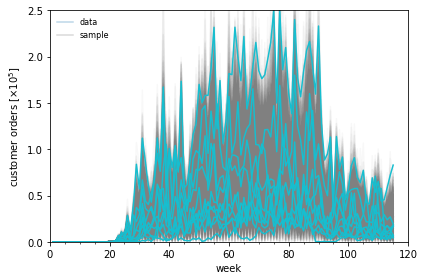

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    #fbd.plot_gaussian_process_vs_model()
    #fbd.plot_distributions()
    fbd.plot_samples_vs_data()


In [9]:
sourcing_parameters = dict(T=fbd.max_weeks)
sourcing_parameters.update(base_cofing)
sourcing_parameters.update(service_configs['high_service'])

In [10]:
N = 1 # aka minibatch size
T = fbd.max_weeks

sds = SequentialDualSourcingModel(**sourcing_parameters)
sds.I_0 = torch.tensor(0.0, requires_grad=True)


In [11]:
class SequentialController(torch.nn.Module):
    def __init__(self, lr, le):
        super().__init__()
        #TODO: query si decoder sequence, i.e. future qs
        #key is past position or value, i.e. positional embedding
        #value is compressed state.        
        # cutoff point is required.
        
        self.layer_norm_1 = torch.nn.LayerNorm([T,1])
        self.initial_guess_nn = torch.nn.Linear(1, 38)
        
        
        self.layer_norm_2 = torch.nn.LayerNorm([T, 2])
        self.sequential_layer = torch.nn.MultiheadAttention(embed_dim=2, num_heads=1, kdim=3, vdim=3, batch_first=True)
        
        self.layer_norm_3 = torch.nn.LayerNorm([T, 2])
        self.output_layer = torch.nn.Linear(2, 38)

        self.lr = lr
        self.le = le
        
        
    def calculate_qs2(self, h):          
        qr_quant = fractional_decoupling(torch.relu(h[:, :, 0]+1)*torch.exp(h[:, :, 1:18].sum(-1)))
        qr_dec = binary_decoupling(h[:, :, 18])
        
        qe_quant = fractional_decoupling(torch.relu(h[:, :, 19]+1)*torch.exp(h[:, :, 20:37].sum(-1)))
        qe_dec = binary_decoupling(h[:, :, 37])
        
        return qr_quant*qr_dec, qe_quant*qe_dec
    
    def calculate_qs(self, h, allow_neg=False):          
        qr_quant = fractional_decoupling(h[:, :, 0] if allow_neg else torch.relu(h[:, :, 0]))
        qr_dec = binary_decoupling(h[:, :, 1])
        
        qe_quant = fractional_decoupling(h[:, :, 2] if allow_neg else torch.relu(h[:, :, 2]))
        qe_dec = binary_decoupling(h[:, :, 3])
        
        return qr_quant*qr_dec, qe_quant*qe_dec
    
    def get_arrived_qs(self, qr, qe):
        arrived_qr = qr.roll(self.lr, dims=(1,)).unsqueeze(-1)
        arrived_qr[:, :self.lr, :] = 0*arrived_qr[:, :self.lr, :]
        
        arrived_qe = qe.roll(self.le, dims=(1,)).unsqueeze(-1)
        arrived_qe[:, :self.le, :] = 0*arrived_qe[:, :self.le, :]
        return arrived_qr, arrived_qe
        
        
    def forward(self, past_demands, I_0, use_causal_mask=True):
        state = I_0 - past_demands
        x = self.layer_norm_1(state.unsqueeze(-1))
        h =  self.initial_guess_nn(x)
        qr, qe = self.calculate_qs2(h)
                
        arrived_qr, arrived_qe = self.get_arrived_qs(qr, qe)
        
        query = torch.stack([qr, qe], -1)
        
        key = torch.cat([past_demands.unsqueeze(-1), arrived_qr, arrived_qe], -1)
        value = key
        
        attn_causal_mask = None
        if use_causal_mask:
            attn_causal_mask = torch.ones((T,T)).tril(diagonal=-1).bool()
            
        attn_output, attn_weights = self.sequential_layer(query, 
                                                          key, 
                                                          value, 
                                                          attn_mask=attn_causal_mask
                                                         )
        
        normed_attn = self.layer_norm_3(attn_output)
        h = self.output_layer(normed_attn)
        nqr, nqe = self.calculate_qs2(h)

                
        return torch.relu(nqr), torch.relu(nqe)

In [12]:
sc = SequentialController(sourcing_parameters['lr'], sourcing_parameters['le'])

In [13]:
best_model = [deepcopy(sc.state_dict())]
best_cost = [np.infty]

In [19]:
optimizer = torch.optim.RMSprop(sc.parameters(), lr=1e-3)
optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)

In [20]:
N=16
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

In [21]:
sc.train()
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
demands = torch.cat([initial_demands, future_demands], dim=-1).float()
past_demands = demands[:, :-1]
compressed_input = (inital_inventories - past_demands).unsqueeze(-1)

for i in range(100000):
    optimizer.zero_grad()
    new_qr, new_qe = sc(past_demands, sds.I_0)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe
    
    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]
    
    
    
    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    mean_costs = costs.mean()
    J = mean_costs#((costs > costs.quantile(0.5, dim=1, keepdim=True))*costs).mean()#mean_costs #+ (1.5*costs.max(dim=0).values).mean()
    

    
    J.backward()
    optimizer.step()
    
    if mean_costs.item() < best_cost[0] and i > 200:
        best_cost[0] = mean_costs.item()
        best_model[0] = deepcopy(sc.state_dict())
    
    if i%2000 == 0 and i > 0:
        future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
        inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
        demands = torch.cat([initial_demands, future_demands], dim=-1).float()
        past_demands = demands[:, :-1]
        compressed_input = (fractional_decoupling(inital_inventories)  - past_demands).unsqueeze(-1)
        print(costs.mean())
        optimizer = torch.optim.RMSprop(sc.parameters(), lr=1e-4)
        optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)

tensor(2584878., grad_fn=<MeanBackward0>)
tensor(2252489.2500, grad_fn=<MeanBackward0>)
tensor(2347494., grad_fn=<MeanBackward0>)
tensor(2398525., grad_fn=<MeanBackward0>)
tensor(2093871.8750, grad_fn=<MeanBackward0>)
tensor(1519614.8750, grad_fn=<MeanBackward0>)
tensor(2459238.7500, grad_fn=<MeanBackward0>)
tensor(1559669.8750, grad_fn=<MeanBackward0>)
tensor(1868400.8750, grad_fn=<MeanBackward0>)
tensor(1671700.3750, grad_fn=<MeanBackward0>)
tensor(1189512.6250, grad_fn=<MeanBackward0>)
tensor(1460399.7500, grad_fn=<MeanBackward0>)
tensor(1725159.2500, grad_fn=<MeanBackward0>)
tensor(1499707.5000, grad_fn=<MeanBackward0>)
tensor(1738693.5000, grad_fn=<MeanBackward0>)


KeyboardInterrupt: 

In [22]:
best_cost

[1173360.5]

In [23]:
sc.load_state_dict(best_model[0])

<All keys matched successfully>

In [24]:
N=1024
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

with torch.no_grad():
    sc.eval()
    future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
    demands = torch.cat([initial_demands, future_demands], dim=-1).float()

    past_demands = demands[:, :-1]
    new_qr, new_qe = sc(past_demands, sds.I_0, True)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe

    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]

    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    print('Mean: ' + str(costs.mean().item()))
    print('Median: ' + str(costs.median().item()))

Mean: 6741676.0
Median: 1345946.0


In [25]:
costs.mean()

tensor(6741676.)

In [26]:
(new_qe > 0).any()

tensor(True)

In [27]:
new_qr

tensor([[6.0000e+00, 7.0000e+00, 9.0000e+00,  ..., 7.7470e+03, 4.9400e+02,
         3.4000e+02],
        [6.0000e+00, 7.0000e+00, 9.0000e+00,  ..., 3.1090e+03, 3.0800e+02,
         2.3200e+02],
        [6.0000e+00, 7.0000e+00, 9.0000e+00,  ..., 5.4560e+03, 4.3500e+02,
         3.0700e+02],
        ...,
        [5.0000e+00, 7.0000e+00, 9.0000e+00,  ..., 3.3200e+03, 4.3900e+02,
         3.1000e+02],
        [5.0000e+00, 7.0000e+00, 9.0000e+00,  ..., 7.0010e+03, 5.2900e+02,
         3.5800e+02],
        [6.0000e+00, 7.0000e+00, 9.0000e+00,  ..., 3.8790e+03, 4.9100e+02,
         3.3900e+02]])

In [28]:
costs

tensor([[5.0000e+01, 8.5000e+01, 1.3000e+02,  ..., 1.4251e+06, 1.3444e+06,
         1.1605e+06],
        [5.0000e+01, 6.0000e+01, 1.2500e+02,  ..., 2.4339e+08, 2.4775e+08,
         2.7212e+08],
        [5.0000e+01, 6.0000e+01, 1.2500e+02,  ..., 1.9530e+05, 1.3537e+06,
         1.8862e+07],
        ...,
        [5.0000e+01, 8.5000e+01, 1.5000e+02,  ..., 3.4265e+06, 3.3206e+06,
         3.2067e+06],
        [7.5000e+01, 9.0000e+01, 1.5500e+02,  ..., 6.4104e+06, 6.3344e+06,
         6.2458e+06],
        [5.0000e+01, 8.5000e+01, 1.3000e+02,  ..., 2.3124e+06, 2.1941e+06,
         1.9918e+06]])

In [29]:
invs

tensor([[ 2.0000e+00,  5.0000e+00,  1.4000e+01,  ...,  2.8489e+05,
          2.6887e+05,  2.3210e+05],
        [ 2.0000e+00,  4.0000e+00,  1.3000e+01,  ..., -4.9168e+05,
         -5.0051e+05, -5.4974e+05],
        [ 2.0000e+00,  4.0000e+00,  1.3000e+01,  ...,  3.8788e+04,
         -2.7344e+03, -3.8105e+04],
        ...,
        [ 2.0000e+00,  5.0000e+00,  1.4000e+01,  ...,  6.8365e+05,
          6.6409e+05,  6.4134e+05],
        [ 3.0000e+00,  6.0000e+00,  1.5000e+01,  ...,  1.2818e+06,
          1.2669e+06,  1.2492e+06],
        [ 2.0000e+00,  5.0000e+00,  1.4000e+01,  ...,  4.6097e+05,
          4.3881e+05,  3.9836e+05]])

In [30]:
demands

tensor([[    0.0000,     0.0000,     0.0000,  ..., 19548.8574, 27421.5137,
         44511.1719],
        [    0.0000,     0.0000,     0.0000,  ..., 20067.5781, 13014.2578,
         52341.7734],
        [    0.0000,     0.0000,     0.0000,  ..., 13195.0986, 49301.5352,
         40827.2891],
        ...,
        [    0.0000,     0.0000,     0.0000,  ..., 23412.5000, 24049.5898,
         26074.0059],
        [    0.0000,     0.0000,     0.0000,  ..., 18735.5625, 25010.1836,
         24713.6445],
        [    0.0000,     0.0000,     0.0000,  ...,  3131.4321, 27465.8340,
         44331.3359]])

In [31]:
new_qe

tensor([[  2.,   3.,   3.,  ...,  31.,   5.,   1.],
        [  2.,   2.,   3.,  ..., 639.,  18.,   2.],
        [  2.,   2.,   3.,  ...,  68.,   6.,   1.],
        ...,
        [  2.,   3.,   4.,  ..., 410.,   5.,   1.],
        [  3.,   3.,   4.,  ...,  83.,   6.,   1.],
        [  2.,   3.,   3.,  ..., 378.,   4.,   1.]])

In [32]:
nn = torch.nn.MultiheadAttention(1, 1, batch_first=True)

In [33]:
Q = torch.rand(100, 10, 1)
K = torch.rand(100, 10, 1)
V = torch.rand(100, 10, 1)

attn_mask = torch.ones([10,10]).tril(diagonal=-1).bool()

In [34]:
nn(Q, K, V, attn_mask=attn_mask)

(tensor([[[-0.2793],
          [-0.2657],
          [-0.2502],
          [-0.2767],
          [-0.2570],
          [-0.2856],
          [-0.2460],
          [-0.2942],
          [-0.2467],
          [-0.2371]],
 
         [[-0.2347],
          [-0.2229],
          [-0.2179],
          [-0.2156],
          [-0.2409],
          [-0.2168],
          [-0.2080],
          [-0.2688],
          [-0.2370],
          [-0.2016]],
 
         [[-0.1451],
          [-0.1375],
          [-0.1013],
          [-0.1106],
          [-0.1081],
          [-0.0697],
          [-0.0794],
          [-0.0485],
          [-0.0708],
          [-0.1128]],
 
         [[-0.2116],
          [-0.2134],
          [-0.1886],
          [-0.1851],
          [-0.1785],
          [-0.1612],
          [-0.1810],
          [-0.2240],
          [-0.2638],
          [-0.4258]],
 
         [[-0.2150],
          [-0.2185],
          [-0.2397],
          [-0.2559],
          [-0.2350],
          [-0.2672],
          [-0.2250],
 